# Cubo Gelatinoso
Heloísa Fernandes Cano - T26

## Enunciado

### Objetivo

<b>Objetivo:</b> Escolha um conjunto de dados que siga as considerações abaixo e estude o desempenho de modelos induzidos pelo algoritmo de <i>k</i> vizinhos mais próximos neste conjunto de dados 
considerando diferentes conjuntos de hiperparâmetros (pelo menos 10 conjuntos de hiperparâmetros 
diferentes). A entrega deve ser realizada em um notebook de Jupyter. A sugestão é que esta seja uma 
entrega com texto direto, sem a necessidade de longos parágrafos. É necessário utilizar o `scikit‑learn`
para induzir os modelos de <i>k</i> vizinhos mais próximos. Não se esqueça de justificar a métrica de 
desempenho escolhida.

### Considerações

<b>Considerações:</b> O conjunto de dados deve ter as seguintes características:
- Pelo menos 5 atributos. Destes atributos, pelo menos um deles deve ser categórico
- Pelo menos 1 target (não há necessidade de mais que 1 target e pode ser um target categórico 
ou numérico, a sua escolha)
- Pelo menos 150 exemplos
- Os dados não podem ser sintéticos


### Expectativas

<b>Expectativas:</b> É esperado que o trabalho siga as boas práticas apresentadas na disciplina, apresente 
resultados de forma gráfica, use seções bem nomeadas e bem divididas no notebook de Jupyter e 
encerre a entrega com uma seção chamada “Conclusões e principais aprendizados”. O trabalho deve 
ter uma seção chamada “Descrição do uso de IA neste trabalho” detalhando como foi a interação com 
ferramentas de IA para a construção dos textos e códigos.

### Pontuação base

<b>Pontuação base:</b> 7 (válida apenas caso o objetivo tenha sido realizado)
Descontos usuais da pontuação base:
- Alguma expectativa não foi atingida
- Trabalho não seguiu boas práticas apresentadas na disciplina. Lembre‑se de revisar o material 
apresentado e suas anotações durante a aula
- Trabalho não apresentou resultados de forma gráfica
- Não guiou o leitor na entrega
- Não interpretou e discutiu os resultados
- Gráfico sem legenda em um ou mais eixos
- Código que acusa erro ao rodar na ordem de cima para baixo
- Entrega sem referências
- Uso incorreto ou omisso de citações (incluindo falta de citação sobre uso de IA)
- Não soube explicar sobre estratégias e códigos utilizados na entrega
- Respostas incorretas às perguntas realizadas pelo professor durante o momento avaliativo
- Respostas incorretas às perguntas realizadas pelo Perguntador 2000™ durante o momento 
avaliativo
- Atraso na entrega do trabalho no Teams

### Pontuação complementar

<b>Pontuação complementar:</b> 3 (cada item abaixo pode valer até no máximo 1 ponto)
- Realizou uma boa análise exploratória dos dados e comparou o desempenho dos modelos com 
relação a um modelo baseline
- Checou como o desempenho dos modelos varia utilizando ou não utilizando dados normalizados de diferentes maneiras
- Checou o desempenho dos modelos variando o número de vizinhos
- Checou o desempenho dos modelos variando a função de distância (considerando pelo menos 
3 funções diferentes)
- Checou o desempenho dos modelos variando a estratégia de codificação do(s) atributo(s) categórico(s)



### Observações e Lembretes

<b>Motivação e aprendizado:</b> Esta é uma tarefa introdutória da disciplina, sendo assim, a motivação 
principal é justamente iniciar sua jornada no campo do Aprendizado de Máquina.

<b>Sugestão de uso de IA nesta tarefa:</b> Um bom uso de IA pode ser para encontrar conjuntos 
de dados de seu interesse. Fora isso, debater com a IA sobre quais atividades complementares fazer, 
ponderando aprendizado e interesse, também é uma boa estratégia.

<b>Lembretes:</b>
- “Guiar o leitor” não é sinônimo de “escrever um livro”. É perfeitamente possível guiar o leitor 
com textos curtos e diretos. Um texto que guia o leitor é aquele que deixa claro o que será 
realizado antes de realizar a tarefa e depois discute o que foi observado.
- Citações devem aparecer o mais próximo possível do local onde a informação foi apresentada 
ao leitor. Ter apenas uma seção de referências sem as devidas citações no texto não é a maneira 
correta de redigir um texto científico e implicará em descontos na pontuação.

## Introdução

https://figshare.com/articles/dataset/Portal_Project_Teaching_Database/1314459

### Importando bibliotecas

In [1]:
import pandas as pd
import random as rd
import seaborn as sns
import statistics as st

semente_aleatoria = 1225

### Leitura do arquivo de dados

A primeira coisa que precisamos fazer é realizar a leitura do arquivo que vamos utilizar. Utilizamos o método `pd.read_csv()` para ler o arquivo `combined.csv`, que contém todos os dados com os quais iremos trabalhar.<br> <br>
<b>Nota:</b> É importante que o arquivo csv esteja na mesma pasta que esse notebook!!

In [2]:
# define o nome do arquivo que vamos ler
arquivo = "combined.csv"

# lê o arquivo
df = pd.read_csv(arquivo, sep=",", header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight,genus,species,taxa,plot_type
1,1,7,16,1977,2,NL,M,32,NaN,Neotoma,albigula,Rodent,Control
2,72,8,19,1977,2,NL,M,31,NaN,Neotoma,albigula,Rodent,Control
3,224,9,13,1977,2,NL,NaN,NaN,NaN,Neotoma,albigula,Rodent,Control
4,266,10,16,1977,2,NL,NaN,NaN,NaN,Neotoma,albigula,Rodent,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34782,26966,10,25,1997,7,PL,M,20,16,Peromyscus,leucopus,Rodent,Rodent Exclosure
34783,27185,11,22,1997,7,PL,F,21,22,Peromyscus,leucopus,Rodent,Rodent Exclosure
34784,27792,5,2,1998,7,PL,F,20,8,Peromyscus,leucopus,Rodent,Rodent Exclosure
34785,28806,11,21,1998,7,PX,NaN,NaN,NaN,Chaetodipus,sp.,Rodent,Rodent Exclosure


## Tratamento e filtro de dados

Agora que lemos o arquivo e o armazenamos em um objeto de data frame, precisamos tratar e filtrar os dados que obtemos. A primeira coisa que podemos perceber quando exibimos o data frame é que as colunas estão identificadas por <b>índices numéricos</b>, e não por o que elas representam. Por outro lado, as colunas estão identificadas estão na primeira linha do data frame, como podemos observar na célula abaixo:

In [3]:
# .iloc[indice] -> imprime uma linha do data frame, dado seu indice
print(df.iloc[0])

0           record_id
1               month
2                 day
3                year
4             plot_id
5          species_id
6                 sex
7     hindfoot_length
8              weight
9               genus
10            species
11               taxa
12          plot_type
Name: 0, dtype: object


Com isso em vista, e também consdierando a documentação do dataset que estamos trabalhando, vamos renomear as colunas de acordo com o que elas representam. Para isso, utilizamoso método `.rename()`. Vamos aproveitar e remover a primeira linha do data frame, já que ela só continha os nomes de cada uma das colunas. Para isso, utilizamos o método `.drop()`:

In [4]:
# renomeia as colunas do data frame com base no index
df = df.rename(columns={0: 'record_id', 
                        1: 'month', 
                        2: 'day', 
                        3: 'year', 
                        4: 'plot_id', 
                        5: 'species_id', 
                        6: 'sex', 
                        7: 'hindfoot_lenght', 
                        8: 'weight', 
                        9: 'genus', 
                        10: 'species', 
                        11: 'taxa', 
                        12: 'plot_type'
                  })
# remove a primeira linha pelo index
df = df.drop( index = 0 )

Agora, se nós exibirmos o data frame novamente, podemos observar que as colunas estão com seus novos nomes e que a primeira linha não é mais dos nomes das colunas:

In [5]:
df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_lenght,weight,genus,species,taxa,plot_type
1,1,7,16,1977,2,NL,M,32,NaN,Neotoma,albigula,Rodent,Control
2,72,8,19,1977,2,NL,M,31,NaN,Neotoma,albigula,Rodent,Control
3,224,9,13,1977,2,NL,NaN,NaN,NaN,Neotoma,albigula,Rodent,Control
4,266,10,16,1977,2,NL,NaN,NaN,NaN,Neotoma,albigula,Rodent,Control
5,349,11,12,1977,2,NL,NaN,NaN,NaN,Neotoma,albigula,Rodent,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34782,26966,10,25,1997,7,PL,M,20,16,Peromyscus,leucopus,Rodent,Rodent Exclosure
34783,27185,11,22,1997,7,PL,F,21,22,Peromyscus,leucopus,Rodent,Rodent Exclosure
34784,27792,5,2,1998,7,PL,F,20,8,Peromyscus,leucopus,Rodent,Rodent Exclosure
34785,28806,11,21,1998,7,PX,NaN,NaN,NaN,Chaetodipus,sp.,Rodent,Rodent Exclosure


O próximo passo é remover as linhas que tiverem alguma informação faltando, já que não queremos que nenhum dado esteja faltando quando formos trabalhar com eles. Para isso, vamos utilizar o método `.dropna()`:

In [6]:
# remove linhas que tenham informações faltando
df = df.dropna()
df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_lenght,weight,genus,species,taxa,plot_type
12,845,5,6,1978,2,NL,M,32,204,Neotoma,albigula,Rodent,Control
14,1164,8,5,1978,2,NL,M,34,199,Neotoma,albigula,Rodent,Control
15,1261,9,4,1978,2,NL,M,32,197,Neotoma,albigula,Rodent,Control
18,1756,4,29,1979,2,NL,M,33,166,Neotoma,albigula,Rodent,Control
19,1818,5,30,1979,2,NL,M,32,184,Neotoma,albigula,Rodent,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34780,26557,7,29,1997,7,PL,F,20,22,Peromyscus,leucopus,Rodent,Rodent Exclosure
34781,26787,9,27,1997,7,PL,F,21,16,Peromyscus,leucopus,Rodent,Rodent Exclosure
34782,26966,10,25,1997,7,PL,M,20,16,Peromyscus,leucopus,Rodent,Rodent Exclosure
34783,27185,11,22,1997,7,PL,F,21,22,Peromyscus,leucopus,Rodent,Rodent Exclosure


Podemos observar que esse passo foi fundamental para nosso tratamento de dados, já que o dataframe antes de ter as linhas com informações faltando tinha 34786 linhas, e agora, depois de ser filtrado, possui apenas 30676.

Como foi apresentado na introduçã, vamos trabalhar apenas com os roedores da tabela. Portanto, vamos filtrar o data frame para que sejam exibidas apenas as linhas cuja coluna `"taxa"` seja igual a `"Rodent"`, utilizando o método `.loc[]`:

In [7]:
# filtra para que só apareçam as linhas sobre roedores
filtro = df['taxa'] == "Rodent"
df = df.loc[filtro]
df

df_teste = df.copy()

Diferentemente de quando removemos as linhas com informações faltando, selecionar apenas os roedores não provocou nenhuma mudança no número de linhas do data frame. Isso mostra que, infelizmente, os outros grupos taxônomicos presentes no data frame (os pássaros, répteis e o coelho) não tinham todas as suas informações na tabela original. :(

### SAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

Antes de decidirmos quais serão as duas espécies que vamos prever, precisamos saber quantos dados de cada uma dessas espécies existem na tabela. Para isso, vamos utilizar o método `.values_counts()` na coluna `species`, para que seja possível visualizar quantos exemplares de cada espécie de roedor ainda estão na tabela depois dos filtros anteriores.

In [8]:
# define a coluna "species" do data frame como um objeto series
serie_species = pd.Series( df["species"] )

# conta quantas vezes cada espécie aparece na tabela, e ordena em ordem decrescente por quantidade.
frequencia_species = serie_species.value_counts()
print(frequencia_species)

species
merriami        9727
penicillatus    2969
baileyi         2803
ordii           2790
megalotis       2417
torridus        2081
spectabilis     2023
flavus          1469
eremicus        1198
albigula        1045
leucogaster      905
maniculatus      835
hispidus         159
fulvescens        73
taylori           45
ochrognathus      40
fulviventer       38
leucopus          35
sp.                9
montanus           8
intermedius        7
Name: count, dtype: int64


Agora, nós queremos que as espécies que vamos tentar prever tenham pelo menos 150 exemplares cada uma. Primeiro, vamos selecionar quais são as espécies que atendem a esse requisito:

In [9]:
# cria uma lista que irá receber quais espécies têm no minimo 150 exemplares
especies_desejadas = []

# itera a lista de frequencia pela espécie registrada e a quantidade
for especie, quantidade in frequencia_species.items():

    # se tiver pelo pelos 150, é uma espécie desejada, entao ela entra na lista
    if quantidade >= 150:
        especies_desejadas.append( especie )

print(f"Total de espécies que atendem ao requisito de pelo menos 150 exemplares encontradas: {len(especies_desejadas)}")
for especie in especies_desejadas:
    print(f"- Espécie '{especie}' atende ao requisito. {frequencia_species[especie]} exemplares registrados")

Total de espécies que atendem ao requisito de pelo menos 150 exemplares encontradas: 13
- Espécie 'merriami' atende ao requisito. 9727 exemplares registrados
- Espécie 'penicillatus' atende ao requisito. 2969 exemplares registrados
- Espécie 'baileyi' atende ao requisito. 2803 exemplares registrados
- Espécie 'ordii' atende ao requisito. 2790 exemplares registrados
- Espécie 'megalotis' atende ao requisito. 2417 exemplares registrados
- Espécie 'torridus' atende ao requisito. 2081 exemplares registrados
- Espécie 'spectabilis' atende ao requisito. 2023 exemplares registrados
- Espécie 'flavus' atende ao requisito. 1469 exemplares registrados
- Espécie 'eremicus' atende ao requisito. 1198 exemplares registrados
- Espécie 'albigula' atende ao requisito. 1045 exemplares registrados
- Espécie 'leucogaster' atende ao requisito. 905 exemplares registrados
- Espécie 'maniculatus' atende ao requisito. 835 exemplares registrados
- Espécie 'hispidus' atende ao requisito. 159 exemplares registrad

Agora que sabemos quais espécies atendem ao novo requisito que estabelecemos, utilizamos o método `isin()` [2] para filtrar apenas as espécies que estejam dentro da lista de "espécies desejadas", junto ao método `.loc[]`.

In [10]:
filtro = df['species'].isin( especies_desejadas )
df = df.loc[filtro]
df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_lenght,weight,genus,species,taxa,plot_type
12,845,5,6,1978,2,NL,M,32,204,Neotoma,albigula,Rodent,Control
14,1164,8,5,1978,2,NL,M,34,199,Neotoma,albigula,Rodent,Control
15,1261,9,4,1978,2,NL,M,32,197,Neotoma,albigula,Rodent,Control
18,1756,4,29,1979,2,NL,M,33,166,Neotoma,albigula,Rodent,Control
19,1818,5,30,1979,2,NL,M,32,184,Neotoma,albigula,Rodent,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34775,32477,8,25,2001,7,PB,M,28,32,Chaetodipus,baileyi,Rodent,Rodent Exclosure
34776,33103,11,17,2001,7,PB,M,28,41,Chaetodipus,baileyi,Rodent,Rodent Exclosure
34777,33305,12,15,2001,7,PB,M,29,44,Chaetodipus,baileyi,Rodent,Rodent Exclosure
34778,34524,7,13,2002,7,PB,M,25,16,Chaetodipus,baileyi,Rodent,Rodent Exclosure


Para vizualizarmos novamente quais espécies ainda estão no data frame e quantos exemplares existem de cada uma de maneira mais clara, utilizamos o método `.value_counts()` novamente.

In [11]:
# define a coluna "species" do data frame como um objeto series
serie_species = pd.Series( df["species"] )

# conta quantas vezes cada espécie aparece na tabela, e ordena em ordem decrescente por quantidade.
frequencia_species = serie_species.value_counts()
print(frequencia_species)

species
merriami        9727
penicillatus    2969
baileyi         2803
ordii           2790
megalotis       2417
torridus        2081
spectabilis     2023
flavus          1469
eremicus        1198
albigula        1045
leucogaster      905
maniculatus      835
hispidus         159
Name: count, dtype: int64


## Explorando os dados

Os dois atributos que serão futuramente utilizados para prever nosso target são o `weight`, correspondente ao <b><u>peso</b></u> do roedor, e o `hindfoot_lenght`, correspondente ao tamanho do <b><u>retropé</u></b> do roedor. Antes de escolhermos quais serão as duas espécies a serem previstas pelo nosso modelo, vamos explorar um pouco esses dois atributos dos nossos roedores.

### Peso e tamanho do retropé médios

Vamos observar o peso e o tamanho de retropé médios de cada um dos nossos roedores. Para isso, vamos realizar os seguintes passos:
1. Criamos o dicionário "roedores", onde vamos armazenar todas as nossas informações, indexadas pela espécie
2. Indexamos as colunas que vamos trabalhar como variáveis individuais, para melhor vizualização
3. Começamos a percorrer as linhas a partir de um índice numérico, com base no comprimento da coluna de espécies.
4. Atribuimos os valores do peso, espécie e retropé da espécie daquela linha em variáveis individuais, para melhor vizualização
5. Se a espécie não estiver no dicionário de roedores:
   - Adicionamos a espécie como uma chave no dicionário, e criamos um novo dicionário como seu valor.
   - Adicionamos e atribuimos valores nas novas chaves dentro do novo dicionário, sendo elas:
     - Peso total, que armazena a soma de todos os pesos daquela espécie
     - Retropé total, que armazena a soma de todas as medidas do retropé daquela espécie
     - Quantidade, que armazena quantos exemplares daquela espécie encontramos
6. Se a espécie já estiver no dicionário de roedores:
   - Adicionamos os valores daquela linha nos valores pré-existentes.


In [12]:
# dicionarios onde armazenaremos os pesos dos roedores
roedores = {}

# define as colunas
coluna_especies = df["species"]
coluna_peso = df["weight"]
coluna_retrope = df["hindfoot_lenght"]

# percorre todos os elementos
for roedor in range ( len(coluna_especies) ):

    # define a especie e o peso do roedorzinho especifico
    especie = coluna_especies.iloc[roedor]
    retrope = int(coluna_retrope.iloc[roedor])
    peso = int(coluna_peso.iloc[roedor])

    # cada espécie tem seu proprio dicionario dentro do dicionario de pesos.
    # se a especie ainda nao estiver no dicionario, cria o dicionario dessa especie e ja adiciona o peso e o tamanho do retrope
    if especie not in roedores:
        roedores[especie] = {}
        roedores[especie]["Pesos individuais"] = [ peso ]
        roedores[especie]["Retropés individuais"] = [ retrope ]
        roedores[especie]["Quantidade"] = 1

    # se ja estiver, só soma nos indices respectivos
    else:
        roedores[especie]["Pesos individuais"].append( peso )
        roedores[especie]["Retropés individuais"].append( retrope )
        roedores[especie]["Quantidade"] += 1

Por fim, imprimimos todas as informações obtidas:

In [13]:
for roedor in roedores:
    print(f"ESPÉCIE: {roedor}") 
    print(f"PESO TOTAL DE TODOS OS EXEMPLARES: {sum(roedores[roedor]["Pesos individuais"])} g")
    print(f"RETROPÉ TOTAL DE TODOS: {sum(roedores[roedor]["Retropés individuais"])} mm")
    print(f"NÚMERO DE EXEMPLARES: {roedores[roedor]["Quantidade"]}")
    print("-")

ESPÉCIE: albigula
PESO TOTAL DE TODOS OS EXEMPLARES: 165930 g
RETROPÉ TOTAL DE TODOS: 33700 mm
NÚMERO DE EXEMPLARES: 1045
-
ESPÉCIE: merriami
PESO TOTAL DE TODOS OS EXEMPLARES: 419584 g
RETROPÉ TOTAL DE TODOS: 350080 mm
NÚMERO DE EXEMPLARES: 9727
-
ESPÉCIE: flavus
PESO TOTAL DE TODOS OS EXEMPLARES: 11687 g
RETROPÉ TOTAL DE TODOS: 22893 mm
NÚMERO DE EXEMPLARES: 1469
-
ESPÉCIE: eremicus
PESO TOTAL DE TODOS OS EXEMPLARES: 25849 g
RETROPÉ TOTAL DE TODOS: 24197 mm
NÚMERO DE EXEMPLARES: 1198
-
ESPÉCIE: spectabilis
PESO TOTAL DE TODOS OS EXEMPLARES: 243218 g
RETROPÉ TOTAL DE TODOS: 101135 mm
NÚMERO DE EXEMPLARES: 2023
-
ESPÉCIE: penicillatus
PESO TOTAL DE TODOS OS EXEMPLARES: 51031 g
RETROPÉ TOTAL DE TODOS: 64586 mm
NÚMERO DE EXEMPLARES: 2969
-
ESPÉCIE: hispidus
PESO TOTAL DE TODOS OS EXEMPLARES: 10311 g
RETROPÉ TOTAL DE TODOS: 4460 mm
NÚMERO DE EXEMPLARES: 159
-
ESPÉCIE: torridus
PESO TOTAL DE TODOS OS EXEMPLARES: 50396 g
RETROPÉ TOTAL DE TODOS: 42175 mm
NÚMERO DE EXEMPLARES: 2081
-
ESPÉCIE:

A próxima etapa é calcular a média dos pesos e das medidas de retropé de cada uma dessas espécies. Para isso, pegamos as somas totais que descobrimos antes e dividimos pela quantidade de exemplares daquela espécie. No fim, imprimimos:

In [14]:
for roedor in roedores:
    
    roedores[roedor]["Peso médio"] = st.mean(roedores[roedor]["Pesos individuais"])
    roedores[roedor]["Retropé médio"] = st.mean(roedores[roedor]["Retropés individuais"])
    
    print(f"ESPÉCIE: {roedor}") 
    print(f"PESO MÉDIO: {round(roedores[roedor]["Peso médio"], 2)} g")
    print(f"RETROPÉ MÉDIO: {round(roedores[roedor]["Retropé médio"])} mm")
    print("-")

ESPÉCIE: albigula
PESO MÉDIO: 158.78 g
RETROPÉ MÉDIO: 32 mm
-
ESPÉCIE: merriami
PESO MÉDIO: 43.14 g
RETROPÉ MÉDIO: 36 mm
-
ESPÉCIE: flavus
PESO MÉDIO: 7.96 g
RETROPÉ MÉDIO: 16 mm
-
ESPÉCIE: eremicus
PESO MÉDIO: 21.58 g
RETROPÉ MÉDIO: 20 mm
-
ESPÉCIE: spectabilis
PESO MÉDIO: 120.23 g
RETROPÉ MÉDIO: 50 mm
-
ESPÉCIE: penicillatus
PESO MÉDIO: 17.19 g
RETROPÉ MÉDIO: 22 mm
-
ESPÉCIE: hispidus
PESO MÉDIO: 64.85 g
RETROPÉ MÉDIO: 28 mm
-
ESPÉCIE: torridus
PESO MÉDIO: 24.22 g
RETROPÉ MÉDIO: 20 mm
-
ESPÉCIE: ordii
PESO MÉDIO: 48.87 g
RETROPÉ MÉDIO: 36 mm
-
ESPÉCIE: leucogaster
PESO MÉDIO: 31.33 g
RETROPÉ MÉDIO: 21 mm
-
ESPÉCIE: megalotis
PESO MÉDIO: 10.58 g
RETROPÉ MÉDIO: 16 mm
-
ESPÉCIE: maniculatus
PESO MÉDIO: 21.34 g
RETROPÉ MÉDIO: 20 mm
-
ESPÉCIE: baileyi
PESO MÉDIO: 31.74 g
RETROPÉ MÉDIO: 26 mm
-


In [15]:
logica = (df_teste["species"] == "megalotis") & (df_teste["weight"] == '26')
rato = df_teste.loc[logica]
rato

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_lenght,weight,genus,species,taxa,plot_type


### Funções de plotagem

colunas -> df [6]

In [16]:
def data_frame_especie(especie):
    global roedores
    
    especie_pesos = roedores[especie]["Pesos individuais"]
    especie_retropes = roedores[especie]["Retropés individuais"]
    
    especie_df = pd.DataFrame({"Peso": especie_pesos, "Retropé": especie_retropes})

    return especie_df

In [17]:
def plotar_grafico(especie, dataframe, eixoX = "Peso", eixoY = "Retropé", pos_legenda = 2):
    global roedores

    contagens = (
        dataframe
        .groupby([eixoX, eixoY])
        .size()
        .reset_index(name="Quantidade")
    )

    
    eixo = sns.scatterplot(
        data=contagens,
        x="Peso",
        y="Retropé",
        hue="Quantidade",
        palette="crest",
        s=60
    )

    eixo.axvline( st.mean( dataframe["Peso"] ), linestyle="dotted", color="red", label="Média do peso")
    eixo.axhline( st.mean( dataframe["Retropé"] ), linestyle="-", color="blue", label="Média do retropé")
    
    #titulo
    titulo = f"Relação entre {eixoX} e {eixoY} da espécie {especie}"
    eixo.set_title( titulo )
    
    #legendas
    eixo.set_xlabel("Peso (g)")
    eixo.set_ylabel("Retropé (mm)")
    eixo.legend(loc = pos_legenda)

## Plotando ratos por peso e pé

### Scatterplot entre peso e retropé da espécie albigula

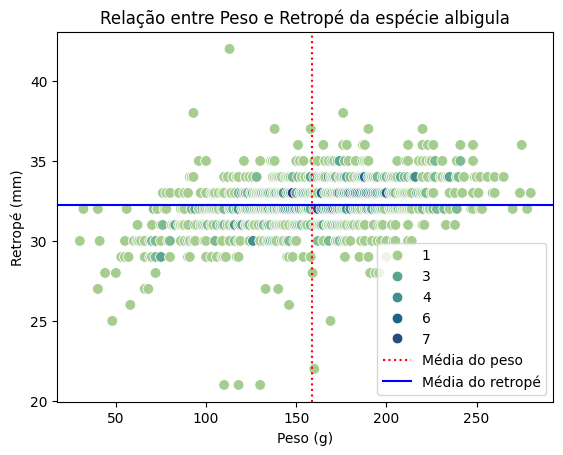

In [18]:
albigula_df = data_frame_especie("albigula")
plotar_grafico("albigula", albigula_df, pos_legenda = 4)

### Scatterplot entre peso e retropé da espécie merriami

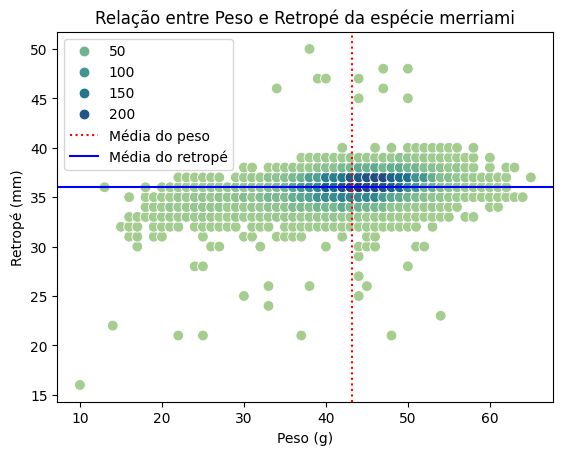

In [19]:
merriami_df = data_frame_especie("merriami")
plotar_grafico("merriami", merriami_df, pos_legenda = 2)

### Scatterplot entre peso e retropé da espécie flavus

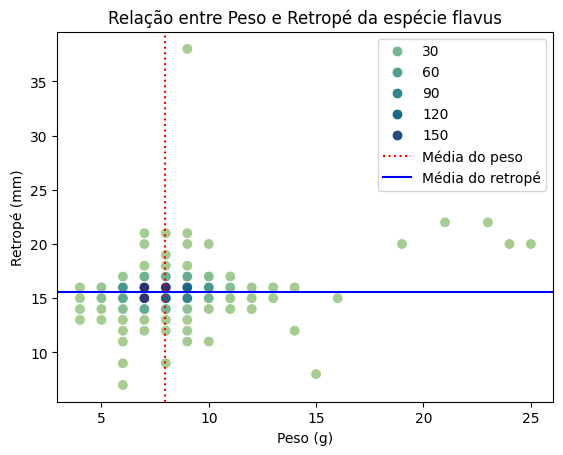

In [20]:
flavus_df = data_frame_especie("flavus")
plotar_grafico("flavus", flavus_df, pos_legenda = 1)

### Scatterplot entre peso e retropé da espécie eremicus

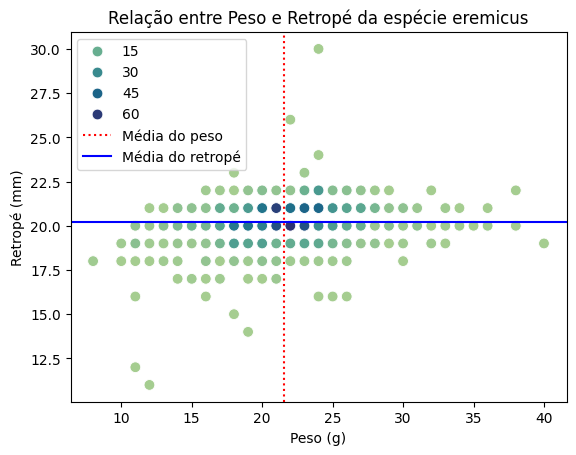

In [21]:
eremicus_df = data_frame_especie("eremicus")
plotar_grafico("eremicus", eremicus_df, pos_legenda = 2)

### Scatterplot entre peso e retropé da espécie spectabilis

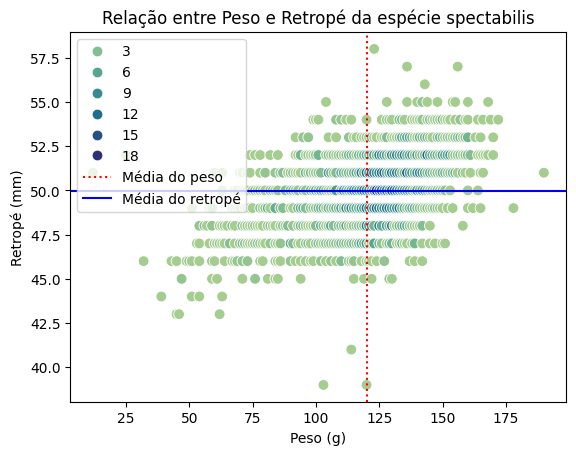

In [22]:
spectabilis_df = data_frame_especie("spectabilis")
plotar_grafico("spectabilis", spectabilis_df, pos_legenda = 2)

### Scatterplot entre peso e retropé da espécie penicillatus

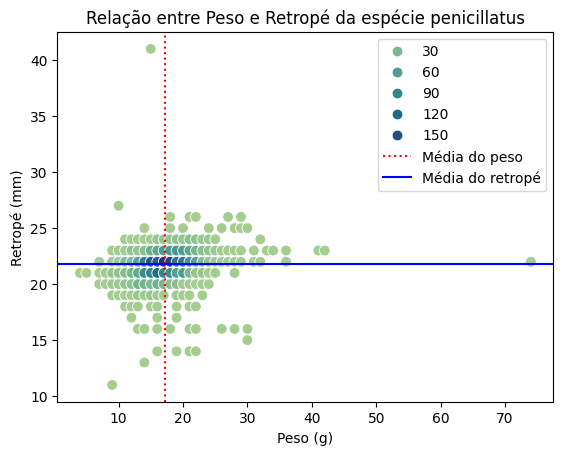

In [23]:
penicillatus_df = data_frame_especie("penicillatus")
plotar_grafico("penicillatus", penicillatus_df, pos_legenda = 1)

### Scatterplot entre peso e retropé da espécie hispidus

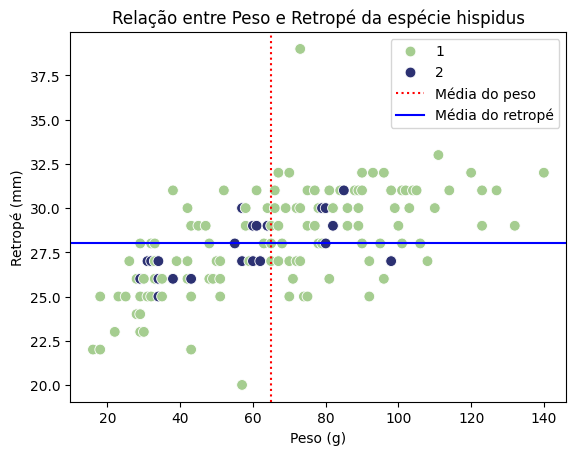

In [24]:
hispidus_df = data_frame_especie("hispidus")
plotar_grafico("hispidus", hispidus_df, pos_legenda = 1)

### Scatterplot entre peso e retropé da espécie torridus

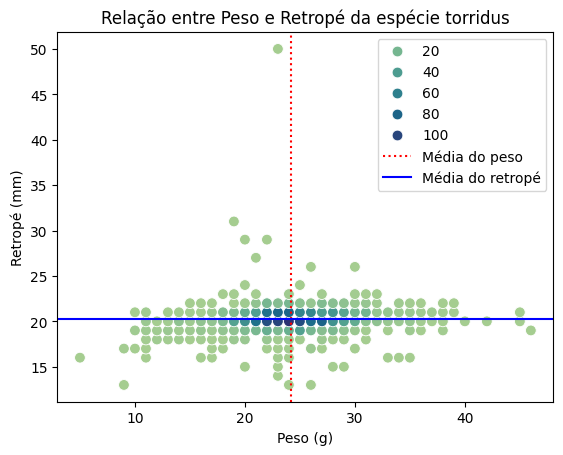

In [25]:
torridus_df = data_frame_especie("torridus")
plotar_grafico("torridus", torridus_df, pos_legenda = 1)

### Scatterplot entre peso e retropé da espécie ordii

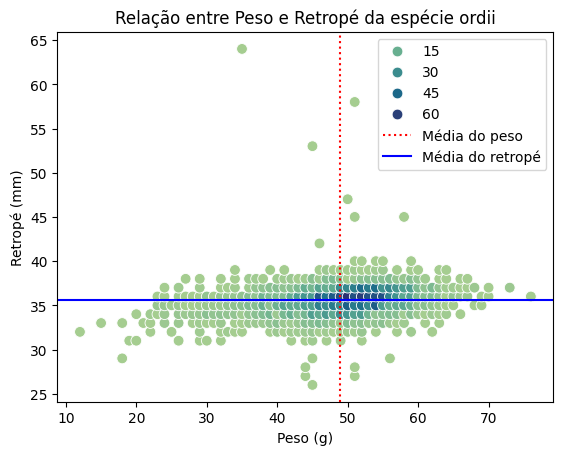

In [26]:
ordii_df = data_frame_especie("ordii")
plotar_grafico("ordii", ordii_df, pos_legenda = 1)

### Scatterplot entre peso e retropé da espécie leucogaster

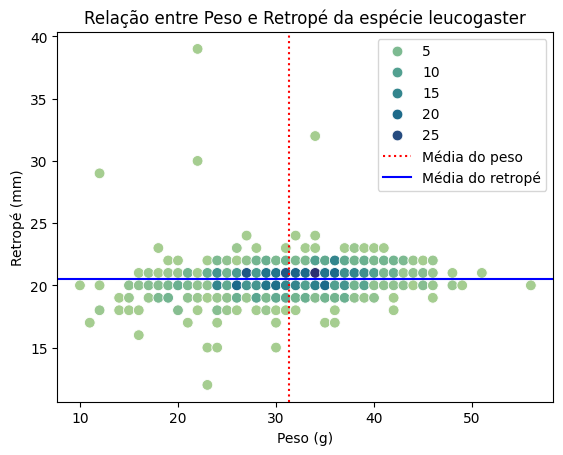

In [27]:
leucogaster_df = data_frame_especie("leucogaster")
plotar_grafico("leucogaster", leucogaster_df, pos_legenda = 1)

### Scatterplot entre peso e retropé da espécie megalotis

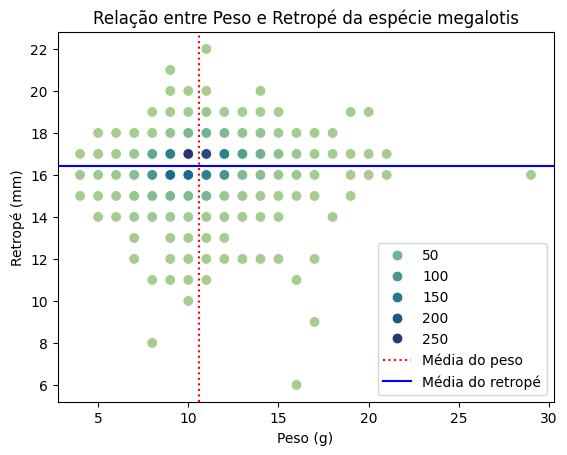

In [28]:
megalotis_df = data_frame_especie("megalotis")
plotar_grafico("megalotis", megalotis_df, pos_legenda = 4)

### Scatterplot entre peso e retropé da espécie maniculatus

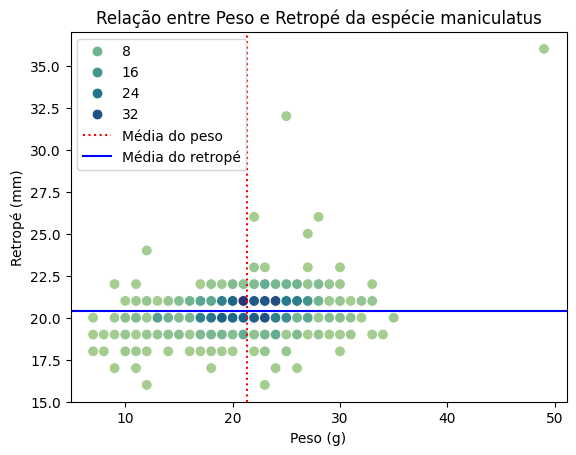

In [29]:
maniculatus_df = data_frame_especie("maniculatus")
plotar_grafico("maniculatus", maniculatus_df, pos_legenda = 2)

### Scatterplot entre peso e retropé da espécie maniculatus

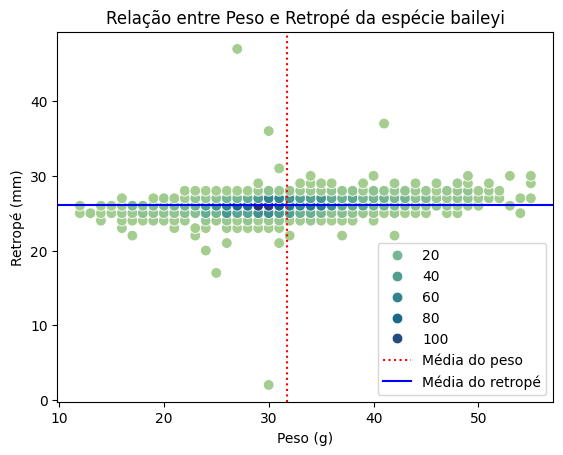

In [30]:
baileyi_df = data_frame_especie("baileyi")
plotar_grafico("baileyi", baileyi_df, pos_legenda = 4)

Como ainda são muitas espécies e precisamos de apenas duas para fazer uma previsão de classificação binária, vamos escolher duas espécies. As espécies escolhidas foram a espécie `ordii`, com 2790 exemplares, e a espécie `spectabilis`, com 2023 exemplares. Vamos filtrar o data frame mais uma vez.

In [31]:
especie_01 = "leucogaster"
especie_02 = "baileyi"

df = df.loc[ df['species'].isin( [especie_01, especie_02] ) ]
df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_lenght,weight,genus,species,taxa,plot_type
1802,274,10,16,1977,2,OL,F,20,21,Onychomys,leucogaster,Rodent,Control
1806,1543,12,3,1978,2,OL,F,22,38,Onychomys,leucogaster,Rodent,Control
1807,1544,12,3,1978,2,OL,M,21,32,Onychomys,leucogaster,Rodent,Control
1808,1573,1,29,1979,2,OL,F,19,31,Onychomys,leucogaster,Rodent,Control
1810,1646,2,25,1979,2,OL,F,20,30,Onychomys,leucogaster,Rodent,Control
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34775,32477,8,25,2001,7,PB,M,28,32,Chaetodipus,baileyi,Rodent,Rodent Exclosure
34776,33103,11,17,2001,7,PB,M,28,41,Chaetodipus,baileyi,Rodent,Rodent Exclosure
34777,33305,12,15,2001,7,PB,M,29,44,Chaetodipus,baileyi,Rodent,Rodent Exclosure
34778,34524,7,13,2002,7,PB,M,25,16,Chaetodipus,baileyi,Rodent,Rodent Exclosure


## Sorteando dados

Porém, ainda temos uma certa diferença na quantidade de dados: existem 2790 exemplares da espécie ordii e 2023 exemplares da espécie spectabilis, com uma diferença de 767. Para que isso não influencie no modelo, vamos sortear 2000 dados de cada uma dessas espécies. [3] semente aleatoria [4] juntar dataframes [5]

In [32]:
df_ordii = df.loc[ df["species"] == especie_01 ]
df_spectabilis = df.loc[ df["species"] == especie_02 ]

tamanho_sample = 800

ordii_aleatorios = df_ordii.sample(tamanho_sample, random_state = semente_aleatoria)
spectabilis_aleatorios = df_spectabilis.sample(tamanho_sample, random_state = semente_aleatoria)

df = pd.merge(ordii_aleatorios, spectabilis_aleatorios, how = 'outer')
df

,record_id,month,day,year,plot_id,species_id,sex,hindfoot_lenght,weight,genus,species,taxa,plot_type
0,10022,2,17,1985,5,OL,F,19,29,Onychomys,leucogaster,Rodent,Rodent Exclosure
1,10029,2,17,1985,11,OL,M,19,33,Onychomys,leucogaster,Rodent,Control
2,10030,2,17,1985,9,OL,F,20,43,Onychomys,leucogaster,Rodent,Spectab exclosure
3,10045,3,16,1985,6,OL,M,21,31,Onychomys,leucogaster,Rodent,Short-term Krat Exclosure
4,10048,3,16,1985,18,OL,F,20,35,Onychomys,leucogaster,Rodent,Short-term Krat Exclosure
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1595,9934,2,16,1985,12,OL,M,21,45,Onychomys,leucogaster,Rodent,Control
1596,9947,2,16,1985,21,OL,M,21,36,Onychomys,leucogaster,Rodent,Long-term Krat Exclosure
1597,9961,2,16,1985,14,OL,F,20,34,Onychomys,leucogaster,Rodent,Control
1598,9966,2,16,1985,14,OL,M,22,35,Onychomys,leucogaster,Rodent,Control


In [33]:
ATRIBUTOS = [ "hindfoot_lenght", "weight"]
TARGET = ["species"]

In [34]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 1225

indices = df.index
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

X_treino = df_treino.reindex(ATRIBUTOS, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

X_teste = df_teste.reindex(ATRIBUTOS, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()

In [35]:
ordem_labels = df["species"].unique().tolist()
ordem_labels

['leucogaster', 'baileyi']

## knn vizinhos

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

NUM_VIZINHOS = 3

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS)
modelo_knn.fit(X_treino, y_treino)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


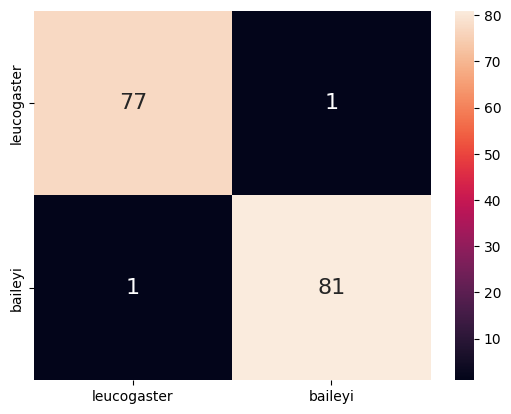

In [37]:
y_verdadeiro = y_teste
y_previsao = modelo_knn.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

In [38]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_verdadeiro, y_previsao)
print(f"Acurácia = {(acuracia*100):.2f}%")

Acurácia = 98.75%


## baseline

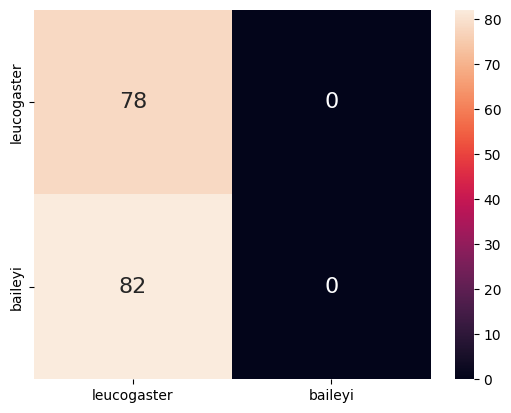

In [39]:
from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier()
modelo_baseline.fit(X_treino, y_treino)

import pandas as pd
from sklearn.metrics import confusion_matrix

y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(X_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

sns.heatmap(df_conf, annot=True, annot_kws={"size": 16});

In [40]:
from sklearn.metrics import accuracy_score

acuracia = accuracy_score(y_verdadeiro, y_previsao)

print(f"Acurácia = {(acuracia*100):.2f}%")

Acurácia = 48.75%


## Uso de inteligência artificial

## Referências

- [2] https://labex.io/pt/tutorials/pandas-pandas-filtering-data-596393
- [3] https://pt.stackoverflow.com/questions/324588/fazer-um-random-de-um-dataset-com-pandas
- [4] https://stackoverflow.com/questions/55748741/how-to-make-a-seed-to-pd-sample-like-np-random-seed
- [5] https://pt.stackoverflow.com/questions/515603/juntar-dois-dataframes-de-mesmo-nome-mantendo-todas-as-colunas
- [6] https://www.geeksforgeeks.org/python/create-a-pandas-dataframe-from-lists/